# 9. LangGraph Basic RAG

## 학습 목표

- Naive RAG 코드를 LangGraph 구조로 바꾼다.
- 검색 노드와 답변 생성 노드를 분리한다.

## 공통 전제

- 실습 데이터: `../data/공직자_민원응대_핵심_매뉴얼.pdf`
- 기본 모델: `gpt-4o-mini`
- 기본 임베딩 모델: `text-embedding-3-small`
- 벡터DB: Qdrant 로컬 인메모리 모드

> 이 노트북은 `src` 파일을 import하지 않고, 노트북 안의 코드만으로 실행되도록 구성한다.

In [10]:
from dotenv import load_dotenv
load_dotenv(override=True, dotenv_path="../../.env")

True

## 1. 문서 준비 완료

## 2. 프롬프트와 유틸 함수

In [11]:
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore

QDRANT_URL = "http://localhost:6333"
COLLECTION_NAME = "civil_complaint_manual_medium"

EMBEDDING_MODEL = "text-embedding-3-small"

embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL)

vector_store = QdrantVectorStore.from_existing_collection(
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    url=QDRANT_URL,
)

In [12]:
from typing_extensions import TypedDict
from langchain_core.documents import Document
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def format_docs(docs: list[Document]) -> str:
    return "\n\n".join([
        f"[근거 {i}] page={doc.metadata.get('page')}, chunk={doc.metadata.get('chunk_id')}\n{doc.page_content}"
        for i, doc in enumerate(docs, start=1)
    ])


rag_prompt = ChatPromptTemplate.from_messages([
    ("system", '''
당신은 공직자 민원응대 매뉴얼 기반 업무지원 AI입니다.
반드시 제공된 근거 문단에 기반하여 답변하세요.

답변 형식:
1. 핵심 대응
2. 단계별 조치
3. 안내 표현
4. 근거
5. 주의사항
'''),
    ("human", '''
질문:
{question}

근거 문단:
{context}
''')
])

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
rag_chain = rag_prompt | llm | StrOutputParser()

## 3. State 정의

In [13]:
class RAGState(TypedDict):
    question:  str             # 사용자 질문 (입력)
    documents: list[Document]  # 검색된 청크 목록
    context:   str             # format_docs() 결과 (프롬프트용)
    answer:    str             # LLM이 생성한 최종 답변 (출력)


## 4. Node 정의

In [14]:
from langgraph.graph import StateGraph, START, END

# ── retrieve 노드 ──────────────────────────────────────
def retrieve_node(state: RAGState) -> dict:
    question = state["question"]
    docs = vector_store.similarity_search(question, k=4)
    context = format_docs(docs)

    return {
        "documents": docs,
        "context": context
    }

# ── generate 노드 ──────────────────────────────────────
def generate_node(state: RAGState) -> dict:
    answer = rag_chain.invoke({
        "question": state["question"],
        "context": state["context"]
    })

    return {
        "answer": answer
    }

## 5. Graph 구성

In [15]:
# 빌더 생성
graph = StateGraph(RAGState)

# 노드 등록
graph.add_node("retrieve", retrieve_node)
graph.add_node("generate", generate_node)

# 엣지 연결
graph.add_edge(START,      "retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", END)

# 컴파일
app = graph.compile()


### 그래프 시각화

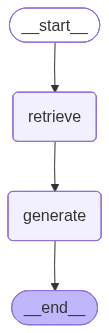

In [16]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## 6. 실행

In [17]:
result = app.invoke({
    "question": "민원인이 기관장과 통화하겠다고 요구하면 어떻게 대응해야 하나요?"
})

print(result["answer"])

1. 핵심 대응  
민원인이 기관장과의 통화를 요구할 경우, 민원인의 요구에 끌려가지 않고 기관의 입장을 설명하며, 담당자가 민원 처리를 맡고 있음을 알리고, 필요한 경우 연락처를 받아서 후속 조치를 취하도록 안내합니다.

2. 단계별 조치  
- **1단계**: 민원인의 요구를 듣고, 통화하고 싶은 이유를 물어봅니다. "선생님, 상급자와 통화하고 싶은 이유가 무엇인지 여쭤봐도 될까요?"  
- **2단계**: 민원인이 요구하는 사항이 무엇인지 확인한 후, "해당 업무는 제가 담당하고 있으며, 도와드릴 수 있는 방법을 찾아보겠습니다."라고 설명합니다.  
- **3단계**: 만약 민원인이 계속해서 기관장과의 통화를 고집할 경우, "선생님 성함과 연락처를 알려주시면 담당 팀장이 연락드리도록 하겠습니다. 잠시만 기다려 주시겠습니까?"라고 안내합니다.

3. 안내 표현  
"선생님, 제가 해당 업무의 담당자입니다. 민원 사항을 말씀해 주시면 최선을 다해 도와드리겠습니다. 만약 기관장과 통화하고 싶으시다면, 성함과 연락처를 남겨주시면 담당 팀장이 연락드리겠습니다."

4. 근거  
민원인의 상급자 통화 요구에 대해서는 "민원은 제가 저희 기관 기관장으로부터 민원처리권한을 위임받은 담당자입니다."라고 설명하며, 민원인의 요구에 끌려가지 말고 기관의 입장을 설명해야 합니다. (근거 2)

5. 주의사항  
민원인의 폭언이나 협박이 있을 경우에는 통화를 종료해야 하며, 장시간 통화가 지속될 경우에는 상담 권장시간을 초과했음을 안내하고 통화를 종료할 수 있습니다. (근거 3)


## 핵심 정리

```text
START → retrieve → generate → END
```

- 기존 Naive RAG 코드를 검색 노드와 답변 생성 노드로 분리했다.
- 이것이 LangGraph Basic RAG의 기본 구조다.
- 다음 단계에서는 질문 분류, 근거 정리, 답변 검증을 추가해 Modular RAG로 확장한다.